# 過分散のある二項分布モデル（ベータ二項分布モデル）

工業製品のロットあたりの不良品数や時間あたりの故障発生数、野球の安打数のような**計数データ**（count data）をモデリングするには、対象とする現象に応じて以下のように二項分布・ポアソン分布を使い分けます。

|確率分布名|モデリング対象の現象|例|
|---|---|---|
|二項分布|$n$回試行した際の発生数$x$|ロットあたり不良品数、野球の安打数|
|ポアソン分布|面積・時間$t$あたりの発生数$x$|機械の時間あたり故障発生数、面積あたり雑草発生数|

このような**二項分布、ポアソン分布を用いた計数データのモデリング**は、現象の**発生確率**（二項分布では成功確率パラメータ$\mu$、ポアソン分布では単位区間あたり平均発生数パラメータ$\mu$）**が一定であることを前提**としています。
発生確率が一定でない場合、以下の図に示すようにデータのばらつきが二項分布・ポアソン分布が予測するよりも大きくなる、**過分散**（overdispersion）と呼ばれる現象が発生します。

過分散が発生している場合、二項分布・ポアソン分布をそのまま使用すると、データの挙動を精度よくモデリングすることができません。代わりに以下のようにベータ二項分布、負の二項分布を用いることで、過分散を考慮したモデリングを実現できます。

- 過分散を含む二項分布：**ベータ二項分布**
- 過分散を含むポアソン分布：**負の二項分布**

ここではベータ二項分布を用いることで過分散を考慮して、$n$回試行した際の発生数$x$に異常検知を適用する方法を解説します。

## ベータ二項分布による異常検知の実装

　[こちらの学習手順、推論手順]()に基づいた異常検知を、Pythonで実装してみます。

今回はモデリングの対象として、書籍の5章でも使用したスリーポイントシュート成功率のデータ[^nba_stats]を使用します。

```csv
PLAYER_ID,AGE,FG3M,FG3A
203932,23.0,121,347
1628988,22.0,43,127
1627846,25.0,32,100
201143,33.0,73,203
202329,28.0,96,280
 :
```

`FG3A`列がスリーポイントシュートの試投数$n$を、`FG3M`列が成功数$x$を表しており、2022年度のデータを学習データ、2023年度のデータを推論データとして用います。

過分散を考慮しない二項分布モデルでは、「平均的な選手よりも偶然の範囲を超えて成功率が高い選手」の検出を目的としていましたが、過分散を考慮するベータ二項分布モデルでは、「**個人差を考慮した上で、偶然の範囲を超えて成功率が高い選手**」を検出することができます。

[^nba_stats]:https://www.nba.com/stats/players/traditional

### 過分散判定

まず、ピアソンのカイ二乗統計量を用いて過分散の有無を判定し、二項分布モデル（過分散なし）とベータ二項分布モデル（過分散あり）のどちらを用いるかを判断します。

In [5]:
# コード 8.101 | 二項分布モデルの過分散の判定
import pandas as pd
import numpy as np

###### 学習データの読込と前処理 ######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('./../datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの成功数x、試行数nを別々に保持してndarray化
x_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

###### ピアソンのカイ二乗統計量を用いて過分散の有無を判定 ######
mu = np.sum(x_train) / np.sum(n_train)  # 発生率パラメータμの最尤推定量
chi2 = np.sum((x_train - n_train * mu) ** 2 / (n_train * mu * (1 - mu)))  # ピアソンのカイ二乗統計量
df = len(x_train) - 1  # 自由度
overdispersion_ratio = chi2 / df  # 過分散比D
print(f'ピアソンのカイ二乗統計量: {chi2:.2f}')
print(f'自由度: {df}')
print(f'過分散比 D: {overdispersion_ratio:.2f}')

ピアソンのカイ二乗統計量: 838.68
自由度: 560
過分散比 D: 1.50


ここでは過分散比Dのしきい値として、よく用いられる1.5を用います。今回はちょうどしきい値上の過分散比となっていますが、過分散ありとみなしてベータ二項分布モデルを用いることとします。

### 学習

　学習フェーズでは、最尤推定による確率分布パラメータの推定を実施します。

SciPyにはベータ二項分布を実装するためのクラス`scipy.stats.betabinom`が用意されていますが、残念ながら最尤推定を実行するための`fit`メソッドが準備されていません。よってまずは以下のように、SciPyの数値最適化用メソッド`scipy.optimize.minimize`関数を用いて、最尤推定を実行する関数を実装します。

In [6]:
# コード 8.102 | ベータ二項分布の最尤推定を実行する関数
import numpy as np
from scipy.stats import betabinom
from scipy.optimize import minimize

def betabinom_neg_log_likelihood(params, x, n):
    """ベータ二項分布の負の対数尤度を計算する関数（数値最適化の目的関数）"""
    alpha, beta = params
    # パラメータa,bは正の値でなければならない
    if alpha <= 0 or beta <= 0:
        return np.inf
    # 確率質量関数の対数の和（データ全体の対数尤度）を計算
    log_pmf_sum = betabinom.logpmf(x, n, alpha, beta).sum()
    # 負の対数尤度を返す
    return -log_pmf_sum

def betabinom_mle(x, n, initial_params=(1.0, 1.0)):
    """ベータ二項分布の最尤推定を実行する関数"""
    result = minimize(
        betabinom_neg_log_likelihood,
        initial_params,
        args=(x, n),
        method='L-BFGS-B',  # 数値最適化のアルゴリズム（L-BFGS-B）
        bounds=[(1e-5, None), (1e-5, None)]  # パラメータalpha,betaは正の値
    )
    if result.success:
        return result.x  # 最適化されたパラメータalpha,betaを返す
    else:
        raise RuntimeError("最尤推定が収束しませんでした。")

この関数を用いて、2022年度のデータを読み込んで最尤推定を実施します。

In [7]:
# コード 8.103 | ベータ二項分布の最尤推定による異常検知の実装例（学習）
import pandas as pd

###### 学習データの読込と前処理 ######
# スリーポイントシュート成功率データ
df_train = pd.read_csv('./../datasets/player_stats_2022.csv')
df_train = df_train[df_train['FG3A'] > 0] # 試投数0を除外
# 学習データの成功数x、試行数nを別々に保持してndarray化
x_train = df_train['FG3M'].to_numpy()
n_train = df_train['FG3A'].to_numpy()

###### 学習ステップ1. 正常のモデルを作成する ######
# ベータ二項分布の最尤推定を実行
alpha, beta = betabinom_mle(x_train, n_train)

###### 学習ステップ2. 異常を表す指標（異常度）を定義する ######
# 式を定義するのみでプログラム上は処理を実施しない

###### 学習ステップ3. 異常度にしきい値を設ける ######
# 推論時に都度算出するので、学習時はしきい値を求めない

###### 学習で求めたパラメータを表示 ######
print(f"alpha={alpha}, beta={beta}")

alpha=100.56908050114423, beta=188.942229218715


推定したパラメータ$\hat{\alpha},\hat{\beta}$に基づき、成功確率パラメータ$\mu$が従うベータ分布を可視化してみます。

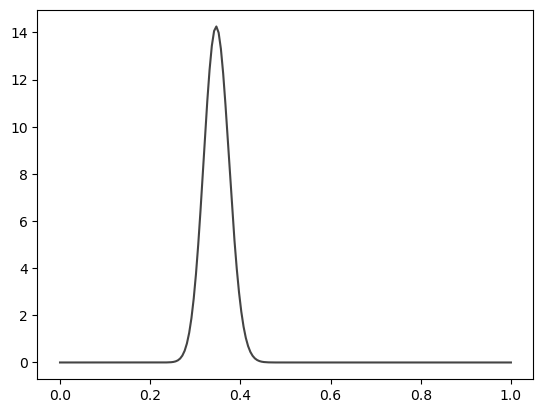

In [8]:
# コード 8.104 | ベータ分布の確率密度関数を描画
from scipy import stats
import matplotlib.pyplot as plt

x = np.linspace(0, 1, 200)  # x軸の値（0から1まで200点）
y = stats.beta.pdf(x, a=alpha, b=beta, loc=0)  # ベータ分布の確率密度関数
plt.plot(x, y, label=fr'$\alpha$={alpha}, $\beta$={beta}', # グラフ描画
         color='#444444')

$\mu$がある程度広がりをもった分布に従っていることが分かります。この広がりが過分散であり、今回のケースでは（真の）スリーポイントシュート成功率の個人差に相当します。このような過分散を考慮したモデルを使用して異常検知を実施することで、二項分布のばらつきだけでなく、個人の能力のばらつきの範囲を超えて成功率が高い選手を検出することができます。

## B. 推論

学習フェーズで推定したパラメータ$\hat{\alpha},\hat{\beta}$と推論データの試投数$n$を用いて、二項分布モデルに基づく以下の式を用いて上下のしきい値$x_{thh},x_{thl}$を求めます。

$x_{thh} = BetaBin_{CDF}^{-1}(1-0.00135 \mid n,\hat{\alpha},\hat{\beta})$

$x_{thl} = BetaBin_{CDF}^{-1}(0.00135 \mid n,\hat{\alpha},\hat{\beta})$

ここで、$BetaBin_{CDF}^{-1}$はベータ二項分布の累積分布関数の逆関数を表し、$0.00135$はターゲットとする誤報率$0.0027\div 2$（両側判定なので2で割る必要がある）を表します。

このしきい値を用いて、以下のコードで推論データのシュート成功数$x$に対して異常判定を行います。

In [9]:
# コード 8.103 | ベータ二項分布の最尤推定による異常検知の実装例（推論）
from scipy import stats

###### 学習したパラメータをここに記載
ALPHA = alpha  # パラメータalpha
BETA = beta    # パラメータbeta

###### 推論データの読み込みと前処理######
# 2023年度のスリーポイントシュート成功率データを推論データとする
df_inference = pd.read_csv("./../datasets/player_stats_2023.csv")
# 試投数5以下を除外（表示の都合上）
df_inference = df_inference[df_inference["FG3A"] > 0]
n_inference = df_inference["FG3A"].to_numpy() # 推論対象の試投数n
x_inference = df_inference["FG3M"].to_numpy() # 推論対象の成功数x

###### 推論を実行######
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
# 下側しきい値（ベータ二項分布の累積分布関数から計算）
th_lowers = stats.betabinom.ppf(TARGET_FP_RATE/2, n=n_inference, a=ALPHA, b=BETA)
# 上側しきい値（ベータ二項分布の累積分布関数から計算）
th_uppers = stats.betabinom.ppf(1 - TARGET_FP_RATE/2, n=n_inference, a=ALPHA, b=BETA)
# しきい値により異常の有無を判定
pred = np.where((x_inference < th_lowers) | (x_inference > th_uppers),
                "anomaly", "normal")

判定のしきい値を超えた選手の一覧をリストアップします。

In [10]:
# 推論結果を表示（しきい値を超えた選手）
df_inference["3P%"] = x_inference / n_inference # 成功率
df_inference["prediction"] = pred
print(df_inference[df_inference["prediction"] == "anomaly"][
      ["PLAYER_ID", "3P%", "FG3A", "FG3M"]].sort_values(
      "3P%", ascending=False).reset_index(drop=True))

   PLAYER_ID       3P%  FG3A  FG3M
0    1628379  0.494424   269   133


検出された`PLAYER_ID`が1628379の選手は、2022年シーズンの選手のばらつきから推測される偶然の範囲を超えて（発生率0.0027以下）、スリーポイントシュート成功率が高いと言えるでしょう。

推論の結果、異常と判定される範囲を推論データと重ねて可視化します。横軸`FG3A`は試投数$n$、縦軸`3P%`は成功率$\frac{x}{n}$ を表します。背景の塗りつぶし色が明るい部分が正常判定、暗い部分が異常判定される範囲を表します。重ねてプロットしている散布図が推論データを、異常判定された選手を黒点で示しています。

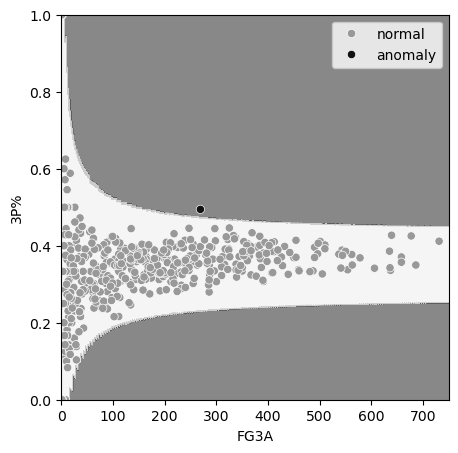

In [11]:
# 正常と異常の境界をプロット
import matplotlib.cm as cm
import seaborn as sns
from sklearn.neighbors import NearestNeighbors

# 描画用のFigureとAxesを生成
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

###### 正常と異常の範囲を色分け ######
# (n,x)格子点を作成
n_list = np.arange(1, 751)
n_grid = np.array(sum([[n for x in range(n+1)] for n in n_list], []))
x_grid = np.array(sum([[x for x in np.arange(n+1)] for n in n_list], []))
mu_grid = x_grid / n_grid  # 観測された発生率μ'=x/n
# 下側しきい値（ベータ二項分布の累積分布関数から計算）
th_lowers = stats.betabinom.ppf(TARGET_FP_RATE/2, n=n_grid, a=ALPHA, b=BETA)
# 上側しきい値（ベータ二項分布の累積分布関数から計算）
th_uppers = stats.betabinom.ppf(1 - TARGET_FP_RATE/2, n=n_grid, a=ALPHA, b=BETA)
# しきい値判定
pred_grid = np.where((x_grid < th_lowers) | (x_grid > th_uppers),
                     0, 1)
# (n,μ)グリッドに判定を近似的に割り当てる
mu_list = np.linspace(0, 1, 500)
X1, X2 = np.meshgrid(n_list, mu_list)
X_neighbor = np.c_[X1.ravel(), X2.ravel()]
knn = NearestNeighbors(n_neighbors=1, algorithm='auto', metric='minkowski')
knn.fit(np.c_[n_grid, mu_grid])
distances, indices = knn.kneighbors(X_neighbor)
pred_neighbor = np.array([
    pred_grid[i]
    for i in indices
])
# 正常と異常の境界をプロット
pred_pivot = pred_neighbor.reshape(X1.shape)
ax.contourf(X1, X2, pred_pivot,
            cmap=cm.gray, alpha=0.5)

###### 各データを散布図としてプロット ######
sns.scatterplot(df_inference, x='FG3A', y='3P%', hue='prediction',
                palette=['#999999', '#111111'], ax=ax)
ax.set_xlim(0, 750)
ax.legend()
# グラフを表示
plt.show()